<a href="https://colab.research.google.com/github/NikethnaSri-AI/Aanseaa_Technologies_Internship/blob/main/date_translation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from datetime import datetime
from calendar import monthrange
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, TimeDistributed, Activation, Add, Concatenate, Attention
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import string
from tensorflow.keras.layers import Attention

In [ ]:
pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 20.6 MB/s eta 0:00:00


In [ ]:
from faker import Faker
import pandas as pd
from datetime import datetime
import random

fake = Faker()

def generate_random_dates(num_samples=10000):
    formats = [
        '%d-%m-%Y', '%d-%b-%Y', '%d-%B-%Y', '%d/%m/%Y',
        '%d/%b/%Y', '%d/%B/%Y', '%d.%m.%Y', '%Y-%m-%d',
        '%d %B %Y', '%d %b %Y', '%B %d, %Y', '%m-%d-%Y',
        '%d %b, %Y', '%d %B, %Y', '%Y%m', '%b-%Y', '%Y. %B'
    ]

    data = []
    for _ in range(num_samples):
        # Generate a random date
        date_obj = fake.date_between(start_date='-30y', end_date='today')
        # Choose a random format from the list
        random_format = random.choice(formats)
        human_readable = date_obj.strftime(random_format)
        machine_readable = date_obj.strftime('%Y-%m-%d')
        data.append([human_readable, machine_readable])

    df = pd.DataFrame(data, columns=['input_date', 'converted_date'])
    return df

# Generate a DataFrame of random dates
df = generate_random_dates(num_samples=10000)

print("Generated data: ")
print(df)


Generated data: 
            input_date converted_date
0           2012-03-16     2012-03-16
1           11-25-2016     2016-11-25
2      03 August, 2007     2007-08-03
3       2023. February     2023-02-15
4           21.09.2017     2017-09-21
...                ...            ...
9995       02/Sep/2014     2014-09-02
9996        05-11-1999     1999-11-05
9997     2011. October     2011-10-04
9998     24 March 2003     2003-03-24
9999  06 November 2002     2002-11-06

[10000 rows x 2 columns]


In [ ]:
df = pd.read_csv('dates.csv')
print('original dataframe: ')
print(df)
df['converted_date'] = df['input_date'].apply(convert_date)
df = df.dropna(subset=['converted_date'])
df.reset_index(drop=True, inplace=True)
print('modified dataframe: ')
print(df)
print(f"Total dates: {len(df)}")

In [ ]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)
print(f"Training set: {len(train_df)} dates")
print(f"Validation set: {len(val_df)} dates")
print(f"Test set: {len(test_df)} dates")

Training set: 474 dates
Validation set: 119 dates
Test set: 149 dates


In [ ]:
def build_char_mapping_and_lengths(df):
    all_dates = df['input_date'].tolist() + df['converted_date'].tolist()
    chars = sorted(list(set(''.join(all_dates))))
    chars = ['<pad>', '<unk>', '<start>', '<end>'] + chars
    char_to_index = {c: i for i, c in enumerate(chars)}
    index_to_char = {i: c for i, c in enumerate(chars)}
    max_encoder_seq_length = max([len(date) for date in df['input_date']])
    max_decoder_seq_length = max([len(date) for date in df['converted_date']]) + 2
    num_tokens = len(chars)
    return char_to_index, index_to_char, num_tokens, max_encoder_seq_length, max_decoder_seq_length

char_to_index, index_to_char, num_tokens, max_encoder_seq_length, max_decoder_seq_length = build_char_mapping_and_lengths(df)
print(char_to_index)
print(index_to_char)
print(num_tokens)
print(max_encoder_seq_length)
print(max_decoder_seq_length)

{'<pad>': 0, '<unk>': 1, '<start>': 2, '<end>': 3, ' ': 4, "'": 5, ',': 6, '-': 7, '.': 8, '/': 9, '0': 10, '1': 11, '2': 12, '3': 13, '4': 14, '5': 15, '6': 16, '7': 17, '8': 18, '9': 19, 'A': 20, 'D': 21, 'F': 22, 'J': 23, 'M': 24, 'N': 25, 'O': 26, 'S': 27, 'a': 28, 'b': 29, 'c': 30, 'e': 31, 'g': 32, 'h': 33, 'i': 34, 'l': 35, 'm': 36, 'n': 37, 'o': 38, 'p': 39, 'r': 40, 's': 41, 't': 42, 'u': 43, 'v': 44, 'y': 45}
{0: '<pad>', 1: '<unk>', 2: '<start>', 3: '<end>', 4: ' ', 5: "'", 6: ',', 7: '-', 8: '.', 9: '/', 10: '0', 11: '1', 12: '2', 13: '3', 14: '4', 15: '5', 16: '6', 17: '7', 18: '8', 19: '9', 20: 'A', 21: 'D', 22: 'F', 23: 'J', 24: 'M', 25: 'N', 26: 'O', 27: 'S', 28: 'a', 29: 'b', 30: 'c', 31: 'e', 32: 'g', 33: 'h', 34: 'i', 35: 'l', 36: 'm', 37: 'n', 38: 'o', 39: 'p', 40: 'r', 41: 's', 42: 't', 43: 'u', 44: 'v', 45: 'y'}
46
18
12


In [ ]:
def encode_sequence(sequence, max_length):
    encoded = [char_to_index.get(char, 0) for char in sequence]
    return pad_sequences([encoded], maxlen=max_length, padding='post')[0]

In [ ]:
def prepare_sequences(df, char_to_index, num_tokens, max_encoder_seq_length, fixed_decoder_seq_length):
    encoder_input_data = np.zeros((len(df), max_encoder_seq_length, num_tokens), dtype='float32')
    decoder_input_data = np.zeros((len(df), fixed_decoder_seq_length, num_tokens), dtype='float32')
    decoder_target_data = np.zeros((len(df), fixed_decoder_seq_length, num_tokens), dtype='float32')
    for i, (input_date, target_date) in enumerate(zip(df['input_date'], df['converted_date'])):
        encoder_sequence = [char_to_index.get(c, char_to_index['<unk>']) for c in input_date]
        encoder_input_data[i, :len(encoder_sequence), :] = np.eye(num_tokens)[encoder_sequence]
        decoder_sequence = [char_to_index.get(c, char_to_index['<unk>']) for c in target_date]
        decoder_input_data[i, :len(decoder_sequence), :] = np.eye(num_tokens)[decoder_sequence]
        for t in range(len(decoder_sequence)):
            decoder_target_data[i, t, decoder_sequence[t]] = 1.0
    return encoder_input_data, decoder_input_data, decoder_target_data

X_train_enc, X_train_dec, y_train = prepare_sequences(train_df, char_to_index, num_tokens, max_encoder_seq_length, max_decoder_seq_length)
X_val_enc, X_val_dec, y_val = prepare_sequences(val_df, char_to_index, num_tokens, max_encoder_seq_length, max_decoder_seq_length)
X_test_enc, X_test_dec, y_test = prepare_sequences(test_df, char_to_index, num_tokens, max_encoder_seq_length, max_decoder_seq_length)

In [ ]:
def attention_layer(hidden_states, encoder_outputs):
    attention_scores = TimeDistributed(Dense(1))(hidden_states)
    attention_scores = Activation('softmax')(attention_scores)
    attention_scores = tf.transpose(attention_scores, [0, 2, 1])
    context_vector = tf.matmul(attention_scores, encoder_outputs)
    context_vector = tf.squeeze(context_vector, axis=1)
    combined_context = Concatenate(axis=-1)([context_vector, hidden_states])
    combined_context = TimeDistributed(Dense(hidden_states.shape[-1]))(combined_context)
    return combined_context, attention_scores

In [ ]:
def build_seq2seq_model_with_attention(num_tokens, embedding_dim=64, hidden_units=128):
    encoder_inputs = Input(shape=(None, num_tokens))
    decoder_inputs = Input(shape=(None, num_tokens))
    encoder_lstm = LSTM(hidden_units, return_sequences=True, return_state=True)
    encoder_outputs, state_h_enc, state_c_enc = encoder_lstm(encoder_inputs)
    decoder_lstm = LSTM(hidden_units, return_sequences=True, return_state=True)
    decoder_outputs, state_h_dec, state_c_dec = decoder_lstm(decoder_inputs, initial_state=[state_h_enc, state_c_enc])
    attention = Attention()([decoder_outputs, encoder_outputs])
    context = Concatenate(axis=-1)([decoder_outputs, attention])
    outputs = Dense(num_tokens, activation='softmax')(context)
    model = Model(inputs=[encoder_inputs, decoder_inputs], outputs=outputs)
    return model

In [ ]:
def train_model(model, X_train_enc, X_train_dec, y_train, X_val_enc, X_val_dec, y_val):
    batch_size = 64
    epochs = 100
    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(
        [X_train_enc, X_train_dec],
        y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_data=([X_val_enc, X_val_dec], y_val),
        callbacks=[early_stopping]
    )
    return history

In [ ]:
def build_inference_models(model, latent_dim, num_tokens):
    encoder_inputs = model.input[0]
    encoder_lstm = model.get_layer('lstm')
    encoder_outputs, state_h_enc, state_c_enc = encoder_lstm(encoder_inputs)
    encoder_model = Model(encoder_inputs, [state_h_enc, state_c_enc])

    decoder_inputs = model.input[1]
    decoder_state_input_h = Input(shape=(latent_dim,))
    decoder_state_input_c = Input(shape=(latent_dim,))
    decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]
    decoder_lstm = model.get_layer('lstm_1')
    decoder_outputs, state_h_dec, state_c_dec = decoder_lstm(decoder_inputs, initial_state=decoder_states_inputs)

    context, _ = attention_layer(decoder_outputs, encoder_outputs)
    decoder_dense = model.get_layer('dense')
    decoder_outputs = decoder_dense(context)
    decoder_model = Model([decoder_inputs] + decoder_states_inputs, [decoder_outputs] + [state_h_dec, state_c_dec])
    return encoder_model, decoder_model

In [ ]:
num_tokens = len(char_to_index)
model = build_seq2seq_model_with_attention(num_tokens)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
history = train_model(model, X_train_enc, X_train_dec, y_train, X_val_enc, X_val_dec, y_val)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - accuracy: 0.1716 - loss: 3.1451 - val_accuracy: 0.4279 - val_loss: 2.9593
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.3984 - loss: 2.7179 - val_accuracy: 0.3214 - val_loss: 1.6073
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.3204 - loss: 1.5575 - val_accuracy: 0.3340 - val_loss: 1.4581
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.3215 - loss: 1.4353 - val_accuracy: 0.3032 - val_loss: 1.3002
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.3101 - loss: 1.2754 - val_accuracy: 0.4615 - val_loss: 1.2107
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.4732 - loss: 1.1908 - val_accuracy: 0.4944 - val_loss: 1.1209
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.4865 - loss: 1.1042 - val_accuracy: 0.5035 - val_loss: 1.0337
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.5083 - loss: 1.0097 - val_accuracy: 0.6373 - val_loss

In [ ]:
print("X_train_enc shape:", X_train_enc.shape)
print("X_train_dec shape:", X_train_dec.shape)
print("y_train shape:", y_train.shape)
print("X_val_enc shape:", X_val_enc.shape)
print("X_val_dec shape:", X_val_dec.shape)
print("y_val shape:", y_val.shape)

X_train_enc shape: (474, 18, 46)
X_train_dec shape: (474, 12, 46)
y_train shape: (474, 12, 46)
X_val_enc shape: (119, 18, 46)
X_val_dec shape: (119, 12, 46)
y_val shape: (119, 12, 46)


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, None, 46)       │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ input_layer_1             │ (None, None, 46)       │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ [(None, None, 128),    │         89,600 │ input_layer[0][0]      │
│                           │ (None, 128), (None,    │                │                        │
│                           │ 128)]                  │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ [(None, None, 128),    │         89,600 │ input_layer_1[0][0],   │
│                           │ (None, 128), (None,    │                │ lstm[0][1], lstm[0][2] │
│                           │ 128)]                  │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ attention (Attention)     │ (None, None, 128)      │              0 │ lstm_1[0][0],          │
│                           │                        │                │ lstm[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, None, 256)      │              0 │ lstm_1[0][0],          │
│                           │                        │                │ attention[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, None, 46)       │         11,822 │ concatenate[0][0]      │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 573,068 (2.19 MB)

 Trainable params: 191,022 (746.18 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 382,046 (1.46 MB)

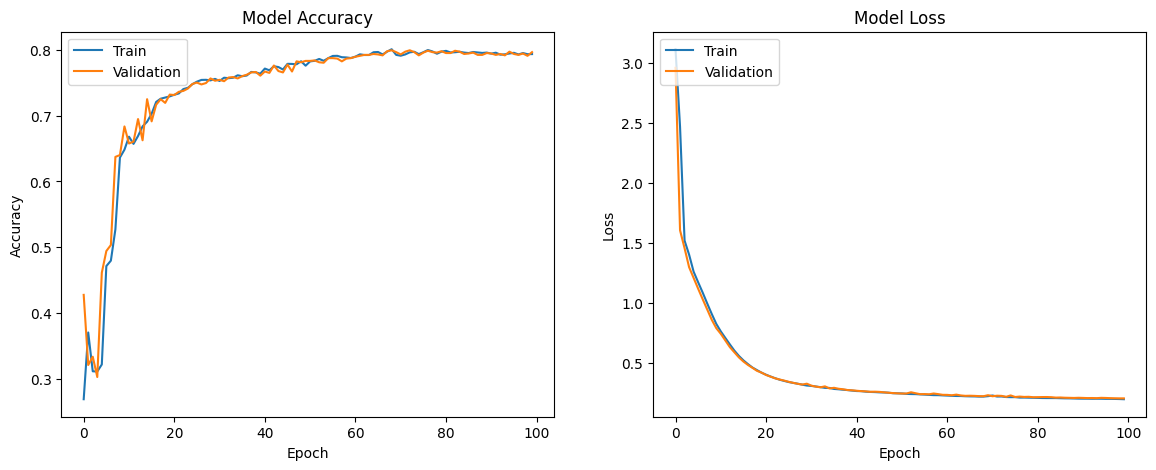

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate([X_test_enc, X_test_dec], y_test, verbose=1)
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7981 - loss: 0.2057
Test Loss: 0.20604251325130463
Test Accuracy: 0.7975391149520874


In [ ]:
def preprocess_new_dates(new_dates, char_to_index, max_encoder_seq_length, fixed_decoder_seq_length):
    encoder_input_data = np.zeros((len(new_dates), max_encoder_seq_length, num_tokens), dtype='float32')
    for i, date in enumerate(new_dates):
        encoded_sequence = encode_sequence(date, max_encoder_seq_length)
        encoder_input_data[i, :len(encoded_sequence), :] = np.eye(num_tokens)[encoded_sequence]
    return encoder_input_data

In [ ]:
def predict_date(model, date, char_to_index, num_tokens, max_encoder_seq_length, max_decoder_seq_length):
    encoder_input_data = preprocess_new_dates([date], char_to_index, max_encoder_seq_length, max_decoder_seq_length)
    decoder_input_data = np.zeros((1, max_decoder_seq_length, num_tokens), dtype='float32')
    decoder_input_data[0, 0, char_to_index['<start>']] = 1.0
    prediction = model.predict([encoder_input_data, decoder_input_data])
    return prediction[0]

In [ ]:
def decode_prediction(prediction, index_to_char):
    date_chars = []
    for char_prob in prediction:
        char_index = np.argmax(char_prob)
        if char_index == char_to_index['<end>']:
            break
        date_chars.append(index_to_char[char_index])
    return ''.join(date_chars)

In [ ]:
input_date = '12-06-2024'
prediction = predict_date(model, input_date, char_to_index, num_tokens, max_encoder_seq_length, max_decoder_seq_length)
predicted_date = decode_prediction(prediction, index_to_char)
print(f"Original Date: {input_date}")
print(f"Predicted Date: {predicted_date}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Original Date: 12-06-2024
Predicted Date: 2024/08/0100


In [ ]:
model.save('my_model.h5')

In [ ]:
from google.colab import files
files.download('my_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>